# Deep DAS event and repeater-family result

This notebook contains the main scientific result from the deep cable. Event **75336682** is spatially coherent on the DAS recording and matches six known earthquakes from the target SAFOD repeater family in the independent seismic-network comparison. The same-fiber control **75343317** is also detectable on DAS but does not match that family.

The family label is provisional because two published catalog partitions disagree. No absolute depth, slip rate, or stress-drop claim is made here.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "outputs" / "deep_das" / "figure_deep_das_family_match.png").is_file())
OUT = ROOT / "outputs" / "deep_das"
STATUS = json.loads((OUT / "figure_deep_das_family_match_status.json").read_text())
display(Markdown(f"**Result:** DAS event `{STATUS['event_id']}` matches six known family earthquakes with median correlation **{STATUS['target_median_correlation']:.3f}** and median timing mismatch **{1000*STATUS['target_median_timing_mismatch_s']:.1f} ms**. The same-fiber control scores **{STATUS['control_median_correlation']:.3f}** and fails the family test."))

**Result:** DAS event `75336682` matches six known family earthquakes with median correlation **0.979** and median timing mismatch **5.2 ms**. The same-fiber control scores **0.391** and fails the family test.

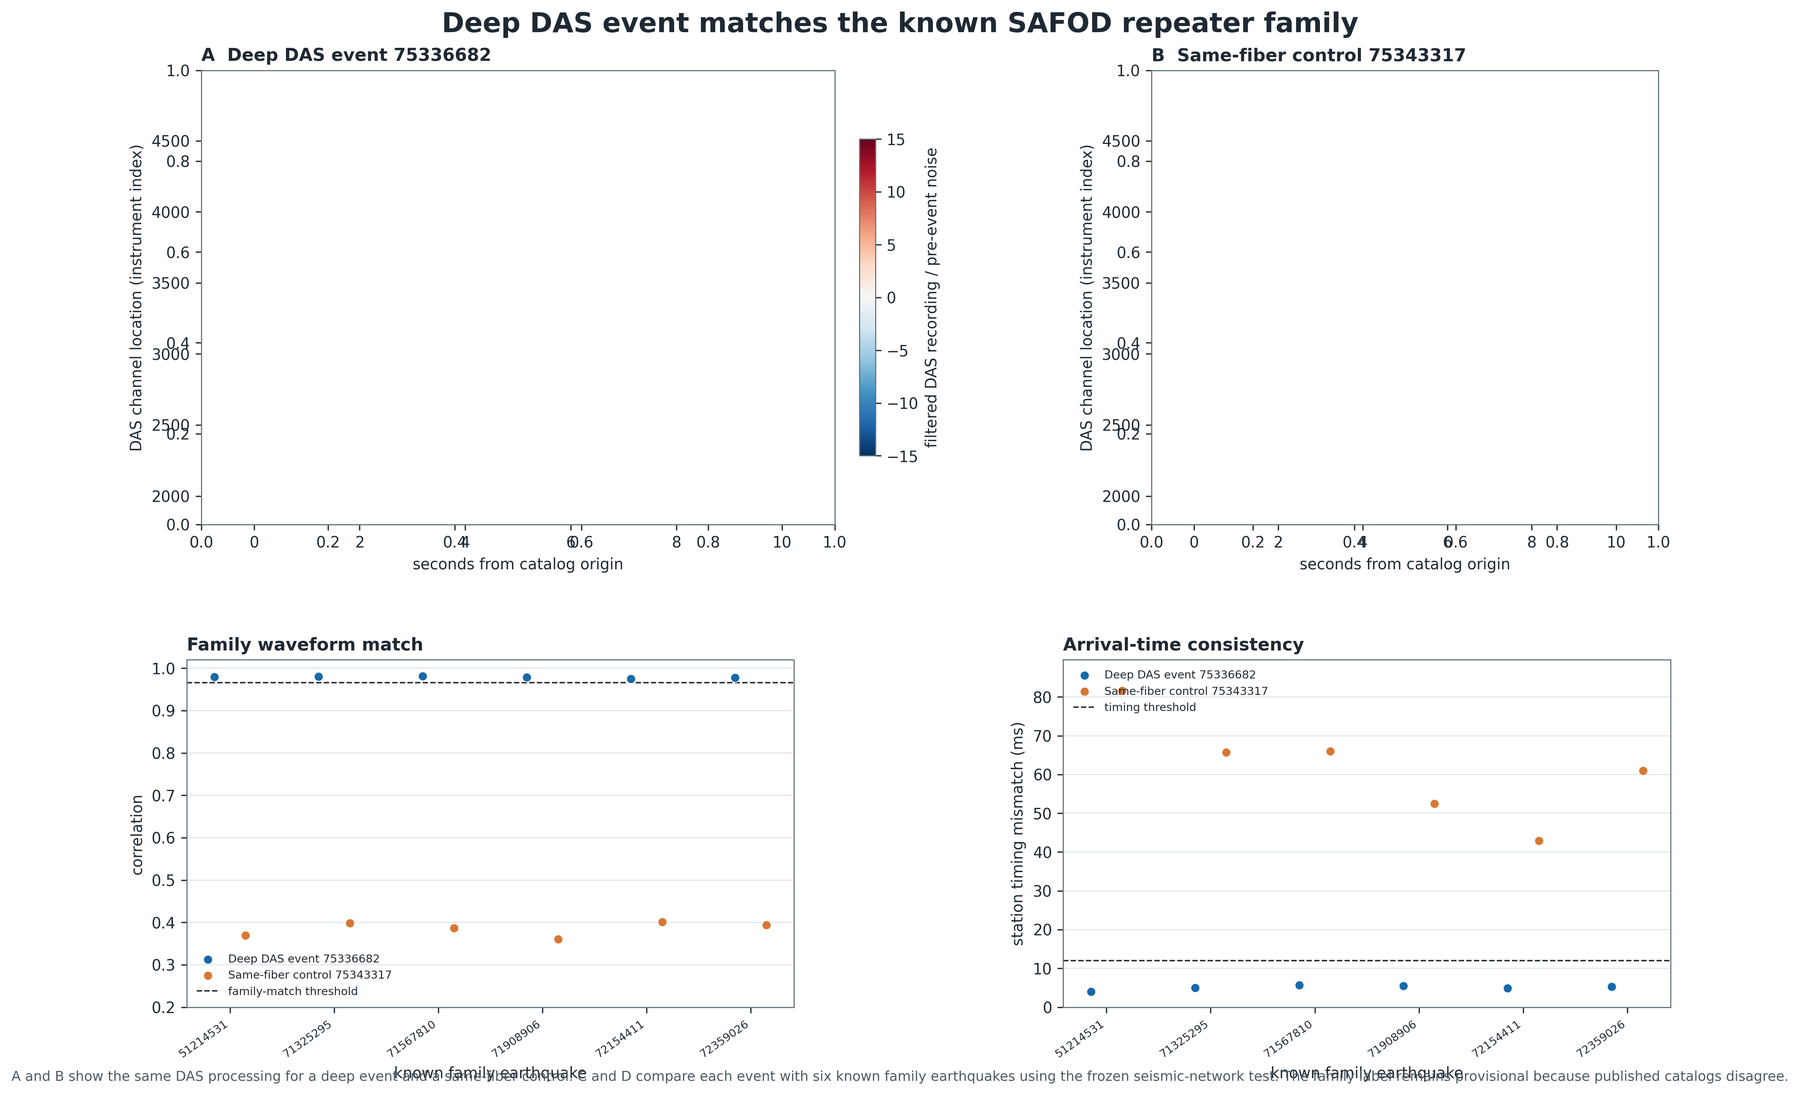

In [2]:
display(Image(filename=str(OUT / "figure_deep_das_family_match.png")))

## What this demonstrates

- The deep DAS recording contains a coherent event at the time of event 75336682.
- The event agrees with six known family earthquakes in independent seismometer recordings.
- A same-fiber control does not pass the family comparison, so the high match is not explained by the cable alone.

This is DAS-assisted family verification, not a completed catalog extension: the event already has a catalog origin, and the family name remains provisional until the published family partitions are reconciled.

In [3]:
features = pd.read_csv(ROOT / "outputs" / "incremental_value" / "deep_named_network" / "anchor_features.csv")
features = features[(features.band_low_hz == 5.0) & (features.band_high_hz == 20.0)]
summary = (features.groupby("comparison_event_id")
           .agg(known_family_earthquakes=("reference_event_id", "nunique"),
                median_correlation=("median_correlation", "median"),
                median_timing_mismatch_ms=("differential_lag_rms_s", lambda x: 1000*x.median()))
           .reset_index())
summary

,comparison_event_id,known_family_earthquakes,median_correlation,median_timing_mismatch_ms
0,75336682,6,0.978975,5.176402
1,75343317,6,0.390702,63.345532


The useful next scientific step is to apply this same test to additional deep-cable earthquakes. One event plus one control is a strong result, but not yet a family-rate or slip-rate measurement.